### The idea behind this notebook:
Let a NN learn the u (displacement) field directly, rather than learning F.

In [1]:
import os
n_cores = 4
os.environ["XLA_FLAGS"] = '--xla_force_host_platform_device_count={}'.format(n_cores)

from jax import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import numpy as np
import pickle
from jax import jit, vmap, grad, jacrev
from jax.lax import cond, scan
import jax.random as random
key = random.PRNGKey(2022)
import jax.example_libraries.optimizers as optimizers
from jax.flatten_util import ravel_pytree
from jax.sharding import PositionalSharding
from functools import partial

import matplotlib.pyplot as plt
import pandas as pd

from utils import train, coords_2_strain_nn, nn_fpass
from utils import train_colloc_parallel as train_colloc, init_params_nn, ff_nn, divergence, bd_forces, a1, a2, lr
from utils_hyperelasticity import NODE, init_layers, NODE_model_aniso,NODE_model_iso,init_params_aniso, init_params_iso, GOH_model, eval_Cauchy, eval_Cauchy_vmap, eval_P, eval_P_vmap
from utils_hyperelasticity import ThreeDElasticity, merge_c_s_params_iso, split_c_s_params_iso
from fem import plotmesh, plotmesh_updated, fe_solver_2D, vahid_anisohyper_inv, apply_bc_biax

from jax_fem.core import FEM
from jax_fem.solver import solver
from jax_fem.utils import save_sol
from jax_fem.generate_mesh import box_mesh, get_meshio_cell_type, Mesh, rectangle_mesh

from PIL import Image, ImageFilter
from jaxinterp2d import interp2d

E_fun = vmap(lambda F: 0.5*(F.T@F - jnp.eye(2)))


with open('/home/amir/inverse_prob/params_for_noise_tuning/manu/image_28_info.npy', 'rb') as f:
    _,_,_,P_xx_gt,P_yy_gt = pickle.load(f)
with open('/home/amir/inverse_prob/params_for_noise_tuning/manu/image28_disp.npy', 'rb') as f:
    x,y,ux_hist,uy_hist = pickle.load(f)
with open('/home/amir/inverse_prob/params_for_noise_tuning/manu/_image28_temp.npy', 'rb') as f:
    E_hist_dic = pickle.load(f)
uy_hist=-uy_hist 

x1 = 4
x2 = 50
y1 = 2
y2 = 48
out = []
for aux in E_hist_dic:
    out.append(aux.transpose([2,0,1]).reshape([51,51,2,2]).transpose([1,0,2,3])[x1:x2,y1:y2,:,:].reshape([-1,2,2])) # I know. wtf?
E_hist_dic = np.array(out)
elem_X = np.stack([x.flatten(),y.flatten()]).T


# we don't need to use all of that data
i1 = 10
i2 = None
skip = 40
P_xx_gt = jnp.array(P_xx_gt[i1:i2:skip])
P_yy_gt = jnp.array(P_yy_gt[i1:i2:skip])
ux_hist = jnp.array(ux_hist[i1:i2:skip])
uy_hist = jnp.array(uy_hist[i1:i2:skip])

E_hist_dic = E_hist_dic[i1:i2:skip]


       __       ___      ___   ___                _______  _______ .___  ___. 
      |  |     /   \     \  \ /  /               |   ____||   ____||   \/   | 
      |  |    /  ^  \     \  V  /      ______    |  |__   |  |__   |  \  /  | 
.--.  |  |   /  /_\  \     >   <      |______|   |   __|  |   __|  |  |\/|  | 
|  `--'  |  /  _____  \   /  .  \                |  |     |  |____ |  |  |  | 
 \______/  /__/     \__\ /__/ \__\               |__|     |_______||__|  |__| 
                                                                              



In [2]:
P_yy_gt

Array([0.20778, 0.92491, 1.50888, 2.02625, 2.50135], dtype=float64)

In [3]:
E_hist_dic.shape

(5, 2116, 2, 2)

In [4]:

ele_type = 'QUAD4'
cell_type = get_meshio_cell_type(ele_type)

Nx, Ny = x.shape[0], x.shape[1]
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
range_minmax=np.zeros((2,2))
disps_norm = []
n_panels = 5
for i in range(len(ux_hist)):
    if i==0:
        range_minmax[0,0]=np.min(ux_hist[i])
        range_minmax[0,1]=np.max(ux_hist[i])
        range_minmax[1,0]=np.min(uy_hist[i])
        range_minmax[1,1]=np.max(uy_hist[i])
    else:
        range_minmax[0,0]=np.min(np.array([range_minmax[0,0],np.min(ux_hist[i])]))
        range_minmax[0,1]=np.max(np.array([range_minmax[0,1],np.max(ux_hist[i])]))
        range_minmax[1,0]=np.min(np.array([range_minmax[1,0],np.min(uy_hist[i])]))
        range_minmax[1,1]=np.max(np.array([range_minmax[1,1],np.max(uy_hist[i])]))


In [5]:
len(ux_hist)

5

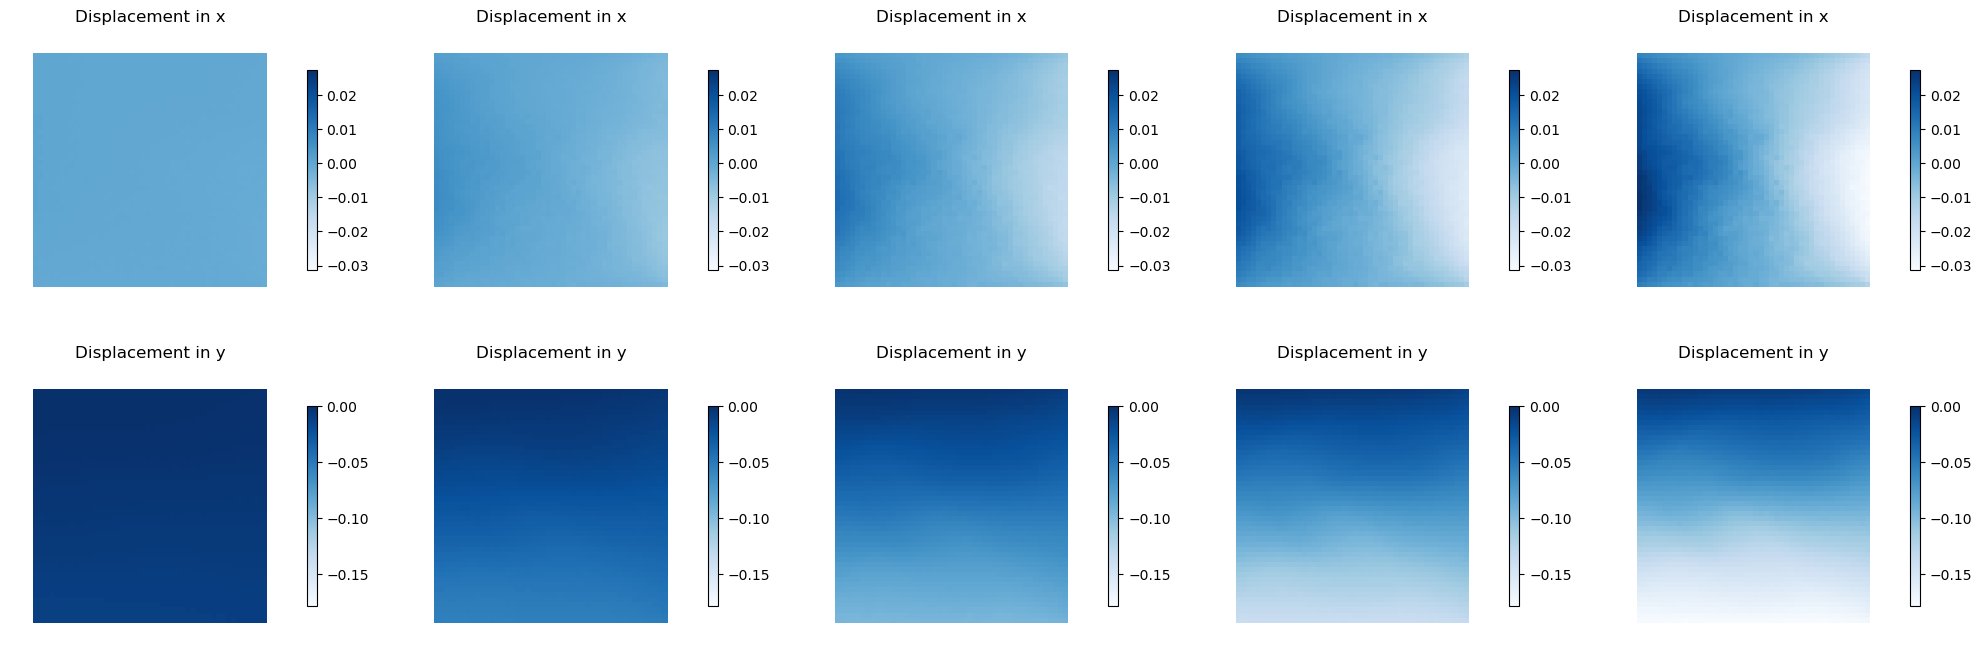

In [6]:
ele_type = 'QUAD4'
cell_type = get_meshio_cell_type(ele_type)

Nx, Ny = x.shape[0], x.shape[1]
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])

disps_norm = []
n_panels = 5
fig, axes = plt.subplots(2,n_panels,figsize=(5*n_panels,8))
t_hist = np.arange(len(ux_hist))
disps_x_mean = []
disps_x_stdv = []
disps_y_mean = []
disps_y_stdv = []
for i in range(len(ux_hist)):
    t = t_hist[i]
    plotmesh_updated(mesh.cells, mesh.points, ux_hist[i].flatten(), \
                     range_minmax[0,0],range_minmax[0,1],title='Displacement in x', ax=axes[0,i], ec='None'); 
    plotmesh_updated(mesh.cells, mesh.points, uy_hist[i].flatten(), \
                     range_minmax[1,0],range_minmax[1,1],title='Displacement in y', ax=axes[1,i], ec='None'); 

    temp1 = ux_hist[i].flatten()
    temp2 = uy_hist[i].flatten()
    disps_x_mean.append(temp1.mean())
    disps_x_stdv.append(temp1.std())
    disps_y_mean.append(temp2.mean())
    disps_y_stdv.append(temp2.std())

    temp1 = (temp1 - temp1.mean())/temp1.std()
    temp2 = (temp2 - temp2.mean())/temp2.std()

    disps_norm.append(np.array([t*np.ones(len(temp1)), temp1, temp2]))
disps_norm = np.hstack(disps_norm)
disps_x_mean = jnp.hstack(disps_x_mean)
disps_x_stdv = jnp.hstack(disps_x_stdv)
disps_y_mean = jnp.hstack(disps_y_mean)
disps_y_stdv = jnp.hstack(disps_y_stdv)

In [7]:
ux_hist=np.array(ux_hist)
uy_hist=np.array(uy_hist)
X_grid=elem_X[:,0].reshape((Nx,Ny)).T
Y_grid=elem_X[:,1].reshape((Nx,Ny)).T[::-1,:]
u_hist_for_derivative=[]
for ii in range(ux_hist.shape[0]):
        ux_hist
        u_hist_for_derivative.append([X_grid,Y_grid,ux_hist[ii,:,:],uy_hist[ii,:,:]])

In [8]:
def richardson_derivative(Z, h):
    """Calculates the derivatives using finite difference and Richardson extrapolation for step size h."""
    Z_x = np.zeros_like(Z)
    Z_y = np.zeros_like(Z)
    rows, cols = Z.shape
    for i in range(rows):
        for j in range(cols):
            if i == 0:  
                Z_y[i, j] = (Z[i + 1, j] - Z[i, j]) / h
            elif i == rows - 1:  
                Z_y[i, j] = (Z[i, j] - Z[i - 1, j]) / h
            else:  
                dy_h = (Z[i + 1, j] - Z[i - 1, j]) / (2 * h)
                
        
                f_y_plus_h_half = (Z[i + 1, j] + Z[i, j]) / 2
                f_y_minus_h_half = (Z[i - 1, j] + Z[i, j]) / 2
                
                dy_h_over_2 = (f_y_plus_h_half - f_y_minus_h_half) / h

               
                #Z_y[i, j] = (4 * dy_h_over_2 - dy_h) / 3
                Z_y[i, j] = dy_h
            if j == 0: 
                Z_x[i, j] = (Z[i, j + 1] - Z[i, j]) / h
            elif j == cols - 1: 
                Z_x[i, j] = (Z[i, j] - Z[i, j - 1]) / h
            else:  
                dx_h = (Z[i, j + 1] - Z[i, j - 1]) / (2 * h)
                
                f_x_plus_h_half = (Z[i, j + 1] + Z[i, j]) / 2
                f_x_minus_h_half = (Z[i, j - 1] + Z[i, j]) / 2
                
                dx_h_over_2 = (f_x_plus_h_half - f_x_minus_h_half) / h

                #Z_x[i, j] = (4 * dx_h_over_2 - dx_h) / 3
                Z_x[i, j] = dx_h

    return Z_x,Z_y
F_with_FDM=np.zeros((5,46*46,2,2))
for ii in range(len(u_hist_for_derivative)):
           a,b,ux_grid,uy_grid=u_hist_for_derivative[ii]
           #print(ux_grid)
           uxx,uxy=richardson_derivative(ux_grid.T,1/(Nx-1))
           #print('derivative')
           #print(uxx)
           uyx,uyy=richardson_derivative(uy_grid.T,1/(Nx-1))
           id_mesh=0
           for i in range(uxx.shape[0]):
                for j in range(uxx.shape[1]):
                     F_with_FDM[ii,id_mesh, :,:]=np.array([[uxx[j,i]+1,uxy[j,i]],[uyx[j,i],uyy[j,i]+1]])
                     id_mesh+=1
#print(uy_grid.T[::-1,:])
# plt.scatter(elem_X[:,0], elem_X[:,1])
# a=elem_X[:,0].reshape((Nx,Ny)).T
# b=elem_X[:,1].reshape((Nx,Ny)).T[::-1,:]
# print(a)
# print(b)


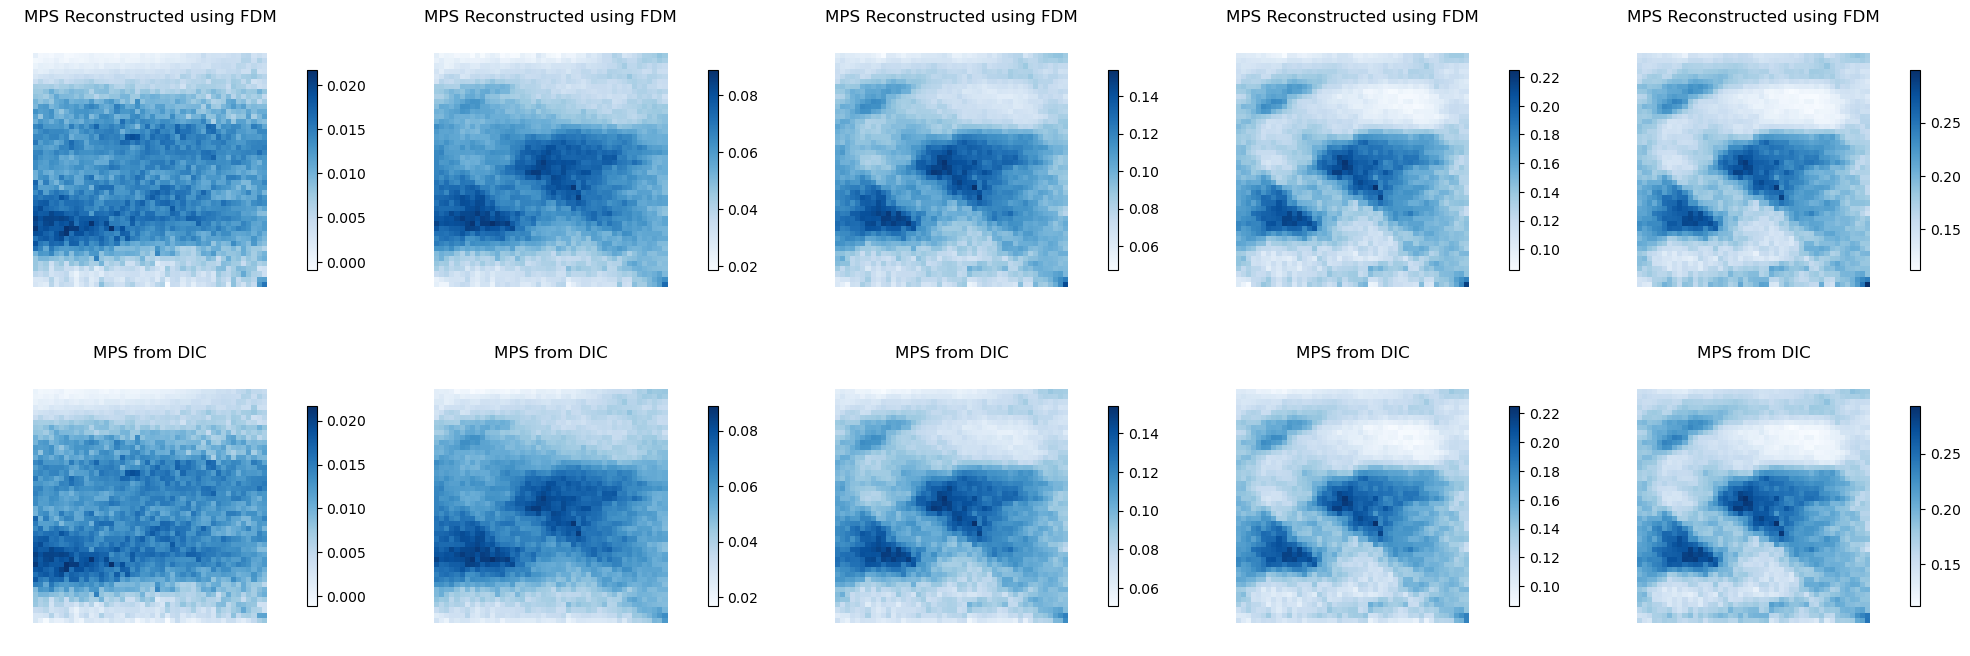

In [9]:
#F_mean = []
fig, axes = plt.subplots(2,5,figsize=(25,8))
for t in t_hist:
    # inp = np.hstack([elem_X, t*np.ones_like(elem_X[:,:1])])
    # F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn2(inp, coord_2_strain_params).T
    F=F_with_FDM[t,:,:]
    # F = np.stack([F_xx, F_xy, F_yx, F_yy]).T.reshape([-1,2,2])
    #F_mean.append(F)
    
    E = E_fun(F)
    evals, efuns = jnp.linalg.eigh(E)
    E_11, E_22 = evals.T
    mps2 = np.maximum(E_11, E_22)

    if t < 5:
        plotmesh(mesh.cells, mesh.points, mps2, title='MPS Reconstructed using FDM', ax=axes[0][t], ec='None'); 


    
    # ground truth
    E = E_hist_dic[t]
    evals, efuns = jnp.linalg.eigh(E)
    E_11, E_22 = evals.T
    mps = np.maximum(E_11, E_22)

    if t < 5:
        plotmesh(mesh.cells, mesh.points, mps, title='MPS from DIC', ax=axes[1][t], ec='None'); 
# F_mean = np.array(F_mean).mean(axis=1)
# F_xx_mean, F_yy_mean, F_xy_mean, F_yx_mean = F_mean[:,0,0], F_mean[:,1,1], F_mean[:,0,1], F_mean[:,1,0]


#### interpolation of FDM

In [10]:

strains = []
t_hist = np.arange(5)
F_hist_goh = []
for t in t_hist:
    F_noisy=F_with_FDM[t,:,:]
    strains.append(np.array([t*np.ones(len(F)), F_noisy[:,0,0], F_noisy[:,0,1], F_noisy[:,1,0], F_noisy[:,1,1]]))
strains = np.hstack(strains)

In [11]:
strains.shape

(5, 10580)

In [ ]:
def loss_coords_2_strain(params, X, key):
    params_fwd=[ff_params, params]
    inp, out_gt = X[:,:3], X[:,3:] #inp: x,y,lmb and out_gt=eps_xx, eps_yy
    t = inp[:,2:3]
    out_pr = coords_2_strain_nn(inp, params_fwd)
    out_gt = out_gt/(t+1) #dividing by t+1 just for some regularization
    out_pr = out_pr/(t+1) #dividing by t+1 just for some regularization
    return jnp.mean((out_pr-out_gt)**2)

n_ff = 100 # 10 cosines and 10 sines in the fourier features
n_inp = 2 # x, y
ff_params = np.random.normal(size=n_inp*n_ff).reshape([n_inp,n_ff])*0.5
nn_layers = [2*n_ff+1,40,40,4]
nn_params = init_params_nn(nn_layers, key)
coord_2_strain_params = nn_params

opt_init, opt_update, get_params = optimizers.adam(5.e-4)
opt_state = opt_init(coord_2_strain_params)

X = np.vstack([elem_X, elem_X, elem_X, elem_X,elem_X])
inp = np.hstack([X, strains.T])
coord_2_strain_params, train_loss, _ = train(loss_coords_2_strain, inp, get_params, opt_update, opt_state, key, nIter = 100000, print_freq=1000, batch_size=1000)

#### plot interpolation and  comparison of $MPS_{gt}$ and $MPS_{NN}$ 

In [13]:
coord_2_strain_params=[ff_params, coord_2_strain_params]

In [14]:
range_minmax=np.zeros((2,))
for t in t_hist:
    aux = np.hstack([elem_X, t*np.ones_like(elem_X[:,:1])])
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn(aux, coord_2_strain_params).T
    F = np.stack([F_xx, F_xy, F_yx, F_yy]).T.reshape([-1,2,2])
    E = E_fun(F)
    evals, efuns = jnp.linalg.eigh(E)
    E_11, E_22 = evals.T
    mps1 = np.maximum(E_11, E_22)
    if t==0:
        range_minmax[0]=np.min(mps1)
        range_minmax[1]=np.max(mps1)
    else:
        range_minmax[0]=np.min(np.array([range_minmax[0],np.min(mps1)]))
        range_minmax[1]=np.max(np.array([range_minmax[1],np.max(mps1)]))

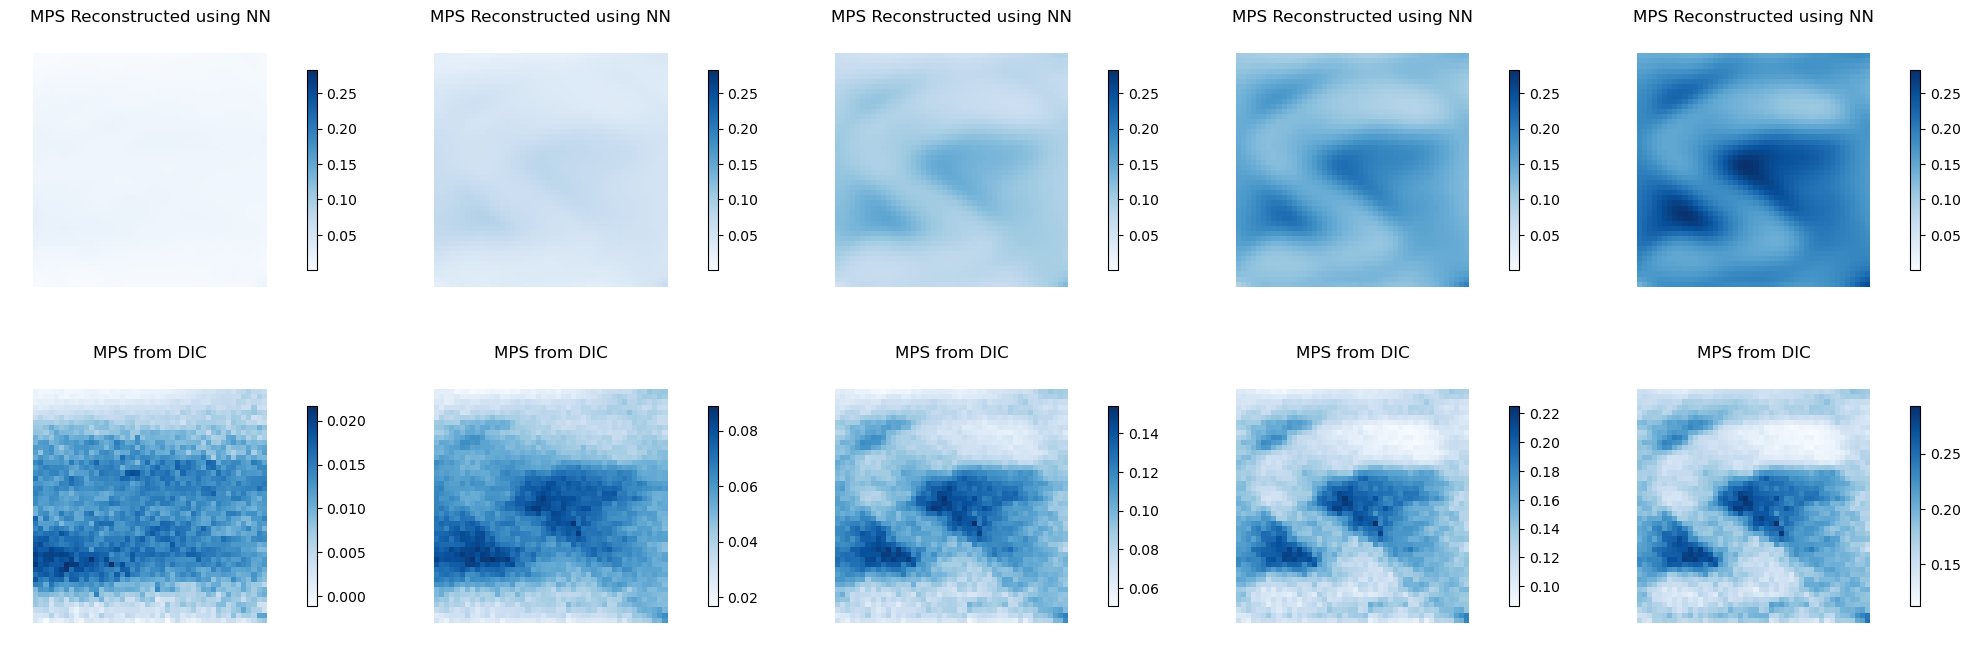

In [15]:
F_mean = []
fig, axes = plt.subplots(2,5,figsize=(25,8))
for t in t_hist:
    aux = np.hstack([elem_X, t*np.ones_like(elem_X[:,:1])])
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn(aux, coord_2_strain_params).T
    F = np.stack([F_xx, F_xy, F_yx, F_yy]).T.reshape([-1,2,2])
    F_mean.append(F )
    E = E_fun(F)
    evals, efuns = jnp.linalg.eigh(E)
    E_11, E_22 = evals.T
    mps1 = np.maximum(E_11, E_22)

    #plotmesh(mesh.cells, mesh.points, mps1, title='MPS Reconstructed using NN', ax=axes[0][t],ec='None')
    plotmesh_updated(mesh.cells, mesh.points, mps1, range_minmax[0],range_minmax[1],title='MPS Reconstructed using NN', ax=axes[0][t],ec='None')
    E = E_hist_dic[t]
    evals, efuns = jnp.linalg.eigh(E)
    E_11, E_22 = evals.T
    mps = np.maximum(E_11, E_22)
    
    plotmesh(mesh.cells, mesh.points, mps, title='MPS from DIC', ax=axes[1][t], ec='None'); 

    #plotmesh(mesh.cells, mesh.points,np.lin, title='MPS from DIC', ax=axes[1][t], ec='None'); 
F_mean = np.array(F_mean).mean(axis=1)
F_xx_mean, F_yy_mean, F_xy_mean, F_yx_mean = F_mean[:,0,0], F_mean[:,1,1], F_mean[:,0,1], F_mean[:,1,0]

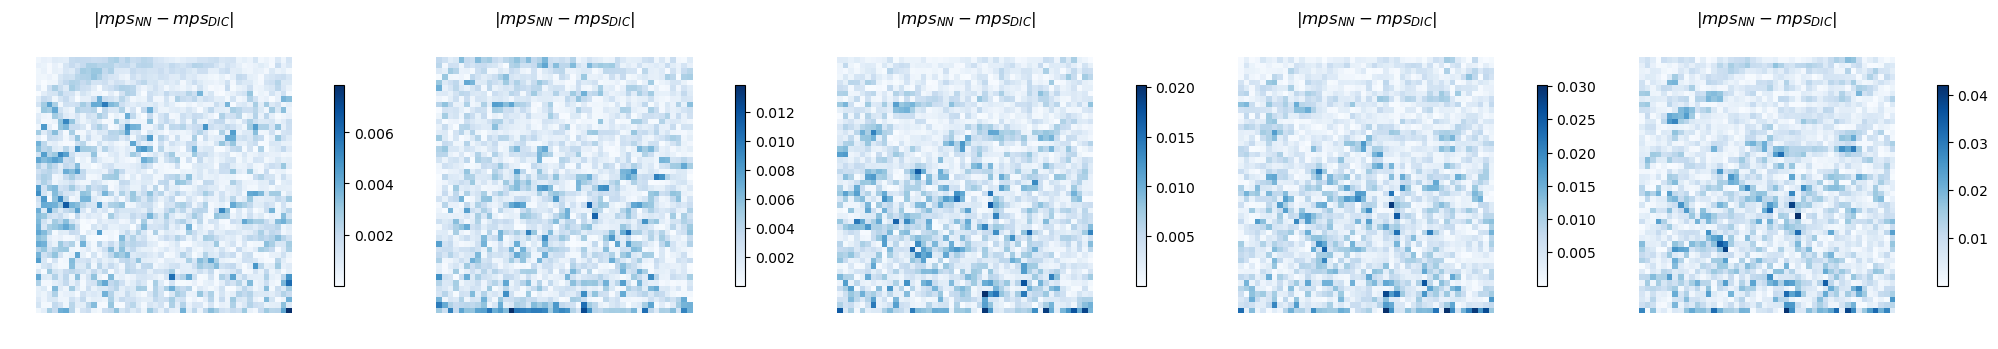

In [16]:
fig, axes = plt.subplots(1,5,figsize=(25,8))
for t in t_hist:
    aux = np.hstack([elem_X, t*np.ones_like(elem_X[:,:1])])
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn(aux, coord_2_strain_params).T
    F = np.stack([F_xx, F_xy, F_yx, F_yy]).T.reshape([-1,2,2])
    
    E = E_fun(F)
    evals, efuns = jnp.linalg.eigh(E)
    E_11, E_22 = evals.T
    mps1 = np.maximum(E_11, E_22)

    E = E_hist_dic[t]
    evals, efuns = jnp.linalg.eigh(E)
    E_11, E_22 = evals.T
    mps = np.maximum(E_11, E_22)
    
    for_error=np.abs(mps-mps1)

    plotmesh(mesh.cells, mesh.points, for_error, title=r'$|mps_{NN}-mps_{DIC}|$', ax=axes[t], ec='None'); 


In [25]:
with open('/home/amir/inverse_prob/params_for_noise_tuning/manu/Experimental_extra1.npy', 'wb') as f:
    pickle.dump([coord_2_strain_params,t_hist, F_xx_mean, F_yy_mean, F_xy_mean, F_yx_mean], f)

In [13]:
with open('/home/amir/inverse_prob/params_for_noise_tuning/manu/Experimental_extra1.npy', 'rb') as f:
    coord_2_strain_params, t_hist, F_xx_mean, F_yy_mean, F_xy_mean, F_yx_mean = pickle.load(f)

In [17]:
#identify the boundaries
rgt_bd_elems = []
top_bd_elems = []
lft_bd_elems = []
bot_bd_elems = []
for i, e in enumerate(mesh.cells):
    if any([mesh.points[e[i],0]>0.99 for i in range(4)]):
        rgt_bd_elems.append(i)
    if any([mesh.points[e[i],1]>0.99 for i in range(4)]):
        top_bd_elems.append(i)
    if any([mesh.points[e[i],0]<0.01 for i in range(4)]):
        lft_bd_elems.append(i)
    if any([mesh.points[e[i],1]<0.01 for i in range(4)]):
        bot_bd_elems.append(i)

# get the reaction forces by integrating the stresses of the boundary elements
rgt_bd_frc = P_xx_gt
lft_bd_frc = P_xx_gt
top_bd_frc = P_yy_gt
bot_bd_frc = P_yy_gt
Force_x = jnp.array(0.5*(rgt_bd_frc + lft_bd_frc))
Force_y = jnp.array(0.5*(top_bd_frc + bot_bd_frc))

#### First Pre-training 

In [22]:
# Homogenize the strains
F_xx_mean = F_xx_mean
F_xy_mean = F_xy_mean
F_yx_mean = F_yx_mean
F_yy_mean = F_yy_mean

P_xx_mean = Force_x
P_yy_mean = Force_y
inputs = np.array([F_xx_mean, F_xy_mean, F_yx_mean, F_yy_mean, P_xx_mean, P_yy_mean]).T
# Define the loss function for when training all params
@jit
def loss_stress(params, x, key):
    model = NODE_model_iso(params)
    F_xx, F_xy, F_yx, F_yy, P_xx_gt, P_yy_gt = x.T
    P = eval_P_vmap(F_xx, F_xy, F_yx, F_yy, model)
    P_xx_pr, P_yy_pr = P[:,0,0], P[:,1,1]
    return np.mean((P_xx_pr-P_xx_gt)**2+(P_yy_pr-P_yy_gt)**2)

# Initialize NODEs and the optimizer
#n_phi = len(phi)

n_neurons = 4
common_layers = [1, n_neurons, n_neurons]
sample_layers = [n_neurons,1]
node_params = init_params_iso(common_layers, sample_layers, key)
common_params, sample_params = split_c_s_params_iso(node_params)
phi, unravel = ravel_pytree(sample_params)
n_phi = len(phi)



# key = random.PRNGKey(0)
# common_layers = [1, n_neurons, n_neurons]
# sample_layers = [n_neurons,1]
# node_params = init_params_iso(common_layers, sample_layers, key)
opt_init, opt_update, get_params = optimizers.adam(5.e-4) #Original: 1.e-4
opt_state = opt_init(node_params)
# Train
node_params, train_loss, _ = train(loss_stress, inputs, get_params, opt_update, opt_state, key, nIter = 20000, print_freq=1000)

it 1000, train loss = 3.874757e-01
it 2000, train loss = 2.527538e-01
it 3000, train loss = 1.967634e-01
it 4000, train loss = 1.700504e-01
it 5000, train loss = 1.608488e-01
it 6000, train loss = 1.579474e-01
it 7000, train loss = 1.568428e-01
it 8000, train loss = 1.563650e-01
it 9000, train loss = 1.561447e-01
it 10000, train loss = 1.560405e-01
it 11000, train loss = 1.559905e-01
it 12000, train loss = 1.559653e-01
it 13000, train loss = 1.559509e-01
it 14000, train loss = 1.559414e-01
it 15000, train loss = 1.559347e-01
it 16000, train loss = 1.559299e-01
it 17000, train loss = 1.559264e-01
it 18000, train loss = 1.559238e-01
it 19000, train loss = 1.559219e-01
it 20000, train loss = 1.559204e-01


In [23]:
mymodel = NODE_model_iso(node_params)
P = eval_P_vmap(F_xx_mean, F_xy_mean, F_yx_mean, F_yy_mean, mymodel)
P_xx_pr, P_yy_pr = P[:,0,0], P[:,1,1]
print('gt P_xx & P_yy: ', P_xx_mean, P_yy_mean)
print('pr P_xx & P_yy: ', P_xx_pr, P_yy_pr)

gt P_xx & P_yy:  [0. 0. 0. 0. 0.] [0.20778 0.92491 1.50888 2.02625 2.50135]
pr P_xx & P_yy:  [0.0764  0.26114 0.38388 0.47025 0.53852] [0.18081 0.8353  1.40673 1.91558 2.37632]


In [24]:
# # Fit a function Λ that maps x,y ∈ [0,1] to the individual-specific parameters of this NODE with a maximum variance of, say, 1%
phi, unravel = ravel_pytree(node_params)
n_phi = len(phi)

# ff_params = coord_2_strain_params[0]
# ff_nn2 = lambda x, nn_params: ff_nn(x, [ff_params, nn_params])
def loss_Lambda(params, inp, key):
    out_pr = ff_nn(inp, params)
    return jnp.mean((out_pr-phi)**2)

n_ff = 100
ff_params = np.random.normal(size=2*n_ff).reshape([2,n_ff])
nn_layers = [2*n_ff,100,50,50,n_phi]
nn_params = init_params_nn(nn_layers, key)
Lambda_params = [ff_params, nn_params]
opt_init, opt_update, get_params = optimizers.adam(5.e-4) #Original: 1.e-4
opt_state = opt_init(Lambda_params)

inp_ = np.array(np.meshgrid(np.linspace(0,1,20), np.linspace(0,1,20))).reshape([2,-1]).T
Lambda_params, train_loss, _ = train(loss_Lambda, inp_, get_params, opt_update, opt_state, key, nIter = 7000, print_freq=1000)

it 1000, train loss = 2.072682e-05
it 2000, train loss = 9.767129e-06
it 3000, train loss = 5.435664e-06
it 4000, train loss = 3.226987e-06
it 5000, train loss = 1.960820e-06
it 6000, train loss = 1.217387e-06
it 7000, train loss = 7.408011e-07


In [28]:
n_phi = len(phi)
print(n_phi)

50


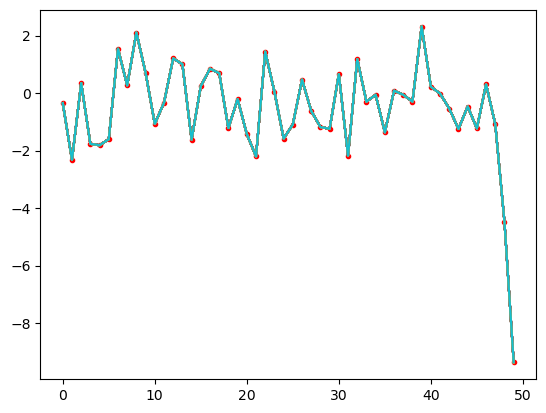

In [29]:
fig, ax = plt.subplots()
ax.plot(phi, 'r.-')
for y in np.linspace(0,1,4):
    for x in np.linspace(0,1,10):
        params = ff_nn(np.array([x,y]).reshape([1,-1]), Lambda_params)
        ax.plot(params[0])

In [30]:
# identify the boundaries
rgt_bd_elems = []
top_bd_elems = []
lft_bd_elems = []
bot_bd_elems = []
for i, e in enumerate(mesh.cells):
    if any([mesh.points[e[i],0]>0.99 for i in range(4)]):
        rgt_bd_elems.append(i)
    if any([mesh.points[e[i],1]>0.99 for i in range(4)]):
        top_bd_elems.append(i)
    if any([mesh.points[e[i],0]<0.01 for i in range(4)]):
        lft_bd_elems.append(i)
    if any([mesh.points[e[i],1]<0.01 for i in range(4)]):
        bot_bd_elems.append(i)

# get the center points of the elements
rgt_bd_X = elem_X[rgt_bd_elems]
top_bd_X = elem_X[top_bd_elems]
lft_bd_X = elem_X[lft_bd_elems]
bot_bd_X = elem_X[bot_bd_elems]
bd_X = rgt_bd_X, top_bd_X, lft_bd_X, bot_bd_X

In [34]:
def loss_stress(Lambda_params, X, key): # X consists of 5 columns: X, Y, lmb (time), ux, uy.
    t = X[2:3].astype(int)
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn(X[:3][None,:], coord_2_strain_params).T
    phi = ff_nn(X[:2][None,:], Lambda_params)
    #node_params = merge_c_s_params_iso(common_params, unravel(phi.flatten()))
    
    model = NODE_model_iso(node_params)
    P = eval_P_vmap(F_xx, F_xy, F_yx, F_yy, model)
    P_xx_pr, P_yy_pr = P[:,0,0], P[:,1,1]
    return np.mean((P_xx_pr - P_xx_gt[t])**2 + (P_yy_pr-P_yy_gt[t])**2)
loss_stress_vmap = lambda a, b, c: np.mean(vmap(loss_stress, in_axes=(None,0,None))(a, b, c))

key = random.PRNGKey(10)
n_neurons = 4
common_layers = [1, n_neurons, n_neurons]
sample_layers = [n_neurons,1]
node_params = init_params_iso(common_layers, sample_layers, key)
common_params, sample_params = split_c_s_params_iso(node_params)
phi, unravel = ravel_pytree(sample_params)
n_phi = len(phi)

# n_ff = 100
# ff_params = np.random.normal(size=2*n_ff).reshape([2,n_ff])
# nn_layers = [2*n_ff,100,50,50,n_phi]
# nn_params = init_params_nn(nn_layers, key)
# Lambda_params = [ff_params, nn_params]
opt_init, opt_update, get_params = optimizers.adam(5.e-4) #Original: 1.e-4
opt_state = opt_init(Lambda_params)

Lambda_params, train_loss, _ = train(loss_stress_vmap, inp, get_params, opt_update, opt_state, key, nIter = 10000, print_freq=1000, batch_size=1000)

it 1000, train loss = 2.422291e+00
it 2000, train loss = 2.581863e+00
it 3000, train loss = 2.558830e+00
it 4000, train loss = 2.505857e+00
it 5000, train loss = 2.585877e+00
it 6000, train loss = 2.552231e+00
it 7000, train loss = 2.389329e+00
it 8000, train loss = 2.464781e+00
it 9000, train loss = 2.431037e+00
it 10000, train loss = 2.488593e+00


In [21]:
n_phi

10

In [42]:
inp.shape

(400, 2)

TypeError: cannot reshape array of shape (41,) (size 41) into shape () (size 1)

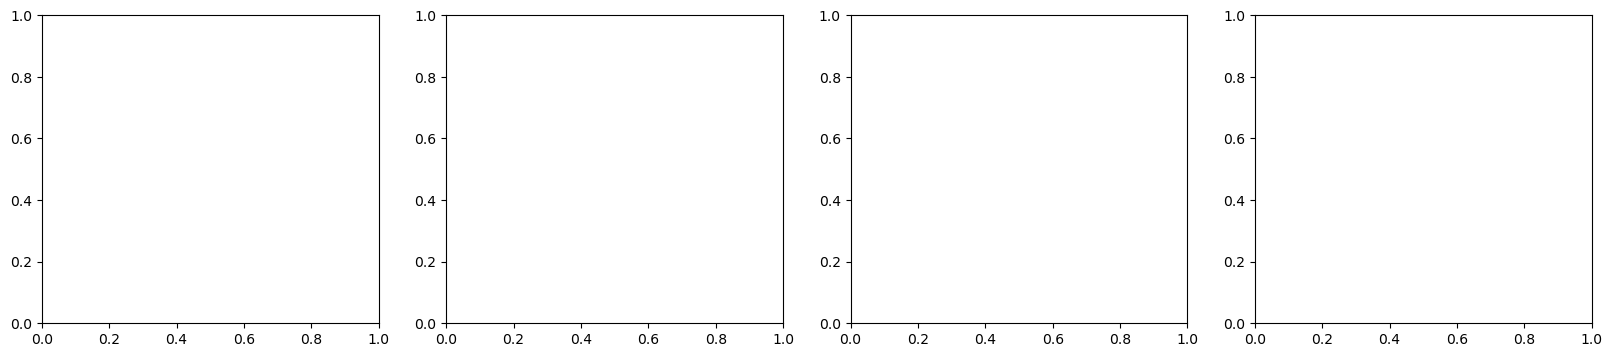

In [33]:
NODE_w_unravel = lambda params: NODE_model_iso(merge_c_s_params_iso(common_params, unravel(params)))

# Stiffness across the domain
fig, axes = plt.subplots(1,4,figsize=(20,4))

for F_xx, F_yy, F_xy, F_yx, ax in zip(F_xx_mean, F_yy_mean, F_xy_mean, F_yx_mean, axes.T):
    F = np.array([[F_xx, F_xy],
                  [F_yx, F_yy]])
    ugrad = F - np.eye(2)
    params_pr = ff_nn(elem_X, Lambda_params)

    c_elem_pr = []
    for params_pr_i in params_pr:
        c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[1,1])
    plotmesh(mesh.cells, mesh.points, c_elem_pr, title='pr stress at $F_{yy}=$' + str(F_yy), ax=ax, ec='None'); 

In [20]:
with open('/home/amir/inverse_prob/params_for_noise_tuning/manu/AM_Extra1_pre.npy', 'wb') as f:
    pickle.dump([coord_2_strain_params, node_params, Lambda_params, mesh, elem_X, P_xx_gt, P_yy_gt,
                 bd_X, t_hist, disps_x_mean, disps_x_stdv, disps_y_mean, disps_y_stdv, Nx, Ny], f)

## 2. Retrain

In [21]:
with open('/home/amir/inverse_prob/params_for_noise_tuning/manu/AM_Extra1_pre.npy', 'rb') as f:
    coord_2_strain_params, node_params, Lambda_params, mesh, elem_X, P_xx_gt, P_yy_gt, \
                 bd_X, t_hist, disps_x_mean, disps_x_stdv, disps_y_mean, disps_y_stdv, Nx, Ny = pickle.load(f)

common_params, sample_params = split_c_s_params_iso(node_params)
_, unravel = ravel_pytree(sample_params)
NODE_w_unravel = lambda params: NODE_model_iso(merge_c_s_params_iso(common_params, unravel(params)))

In [40]:
# with open('/home/amir/inverse_prob/params_for_noise_tuning/manu/AM_stiff2_pre_for_cluster.npy', 'wb') as f:
#     pickle.dump([coord_2_strain_params, node_params, Lambda_params, mesh.points, elem_X, P_xx_gt, P_yy_gt,
#                  bd_X, t_hist, disps_x_mean, disps_x_stdv, disps_y_mean, disps_y_stdv, Nx, Ny], f)

In [23]:
# Train
with open('/home/amir/inverse_prob/params_for_noise_tuning/manu/AM_Extra1_pre.npy', 'rb') as f:
    coord_2_strain_params, node_params, Lambda_params, mesh, elem_X, P_xx_gt, P_yy_gt, \
                 bd_X, t_hist, disps_x_mean, disps_x_stdv, disps_y_mean, disps_y_stdv, Nx, Ny = pickle.load(f)
def get_P(X, Y, t, Lambda_params, coord_2_strain_params, model):
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn(jnp.array([X,Y,t])[None,:], coord_2_strain_params).flatten()
    # get NODE individual-specific params, phi, from the Lambda NN
    Lambda_inp = jnp.array([X,Y]).reshape([-1,2])
    phi = ff_nn(Lambda_inp, Lambda_params).flatten()
    # Make predictions with this NODE
    ugrad = jnp.array([[F_xx-1.0, F_xy],[F_yx, F_yy-1.0]])
    P = ThreeDElasticity(model).ugrad_2_P(ugrad, phi, 2)
    return P[0,0], P[1,0], P[0,1], P[1,1]
get_P_vmap = vmap(get_P, in_axes=(0,0,0,None,None,None), out_axes=(0,0,0,0))

get_Pxx = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[0]
get_Pyx = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[1]
get_Pxy = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[2]
get_Pyy = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[3]

Grad_Pxx_X = vmap(grad(get_Pxx, argnums=0), in_axes=(0,0,0,None,None,None), out_axes=0) # should return dsgm_xx/dx
Grad_Pyx_X = vmap(grad(get_Pyx, argnums=0), in_axes=(0,0,0,None,None,None), out_axes=0)
Grad_Pxy_Y = vmap(grad(get_Pyx, argnums=1), in_axes=(0,0,0,None,None,None), out_axes=0)
Grad_Pyy_Y = vmap(grad(get_Pyy, argnums=1), in_axes=(0,0,0,None,None,None), out_axes=0)

@partial(jit, static_argnums=(4,))
def bd_forces(Lambda_params, t, bd_X, c2s_params, model):
    rgt_bd_X, top_bd_X, lft_bd_X, bot_bd_X = bd_X
    rgt_bd_P = get_P_vmap(rgt_bd_X[:,0], rgt_bd_X[:,1], t*jnp.ones_like(rgt_bd_X[:,0]), Lambda_params, c2s_params, model)
    top_bd_P = get_P_vmap(top_bd_X[:,0], top_bd_X[:,1], t*jnp.ones_like(top_bd_X[:,0]), Lambda_params, c2s_params, model)
    lft_bd_P = get_P_vmap(lft_bd_X[:,0], lft_bd_X[:,1], t*jnp.ones_like(lft_bd_X[:,0]), Lambda_params, c2s_params, model)
    bot_bd_P = get_P_vmap(bot_bd_X[:,0], bot_bd_X[:,1], t*jnp.ones_like(bot_bd_X[:,0]), Lambda_params, c2s_params, model)

    rgt_bd_frc = jnp.sum(rgt_bd_P[0]*1.0) # Assume area of edge = 1.0
    top_bd_frc = jnp.sum(top_bd_P[3]*1.0)
    lft_bd_frc = jnp.sum(lft_bd_P[0]*1.0)
    bot_bd_frc = jnp.sum(bot_bd_P[3]*1.0)
    return rgt_bd_frc, top_bd_frc, lft_bd_frc, bot_bd_frc
@partial(jit, static_argnums=(3,))
def divergence(Lambda_params, XYt, c2s_params, model):
    dPxx_dX = Grad_Pxx_X(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPxy_dY = Grad_Pxy_Y(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPyx_dX = Grad_Pyx_X(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPyy_dY = Grad_Pyy_Y(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    
    Div_X = jnp.mean(dPxx_dX + dPxy_dY)
    Div_Y = jnp.mean(dPyx_dX + dPyy_dY)
    return Div_X, Div_Y
a1 = 1.0
a2 = 1.0
@jit
def loss(Lambda_params, XYt_colloc):
    Div_x, Div_y = divergence(Lambda_params, XYt_colloc, coord_2_strain_params, NODE_w_unravel)
    loss_Div = a1*(Div_x**2 + Div_y**2)

    def bd_forces_loss(_, t):
        F_rgt, F_top, F_lft, F_bot = bd_forces(Lambda_params, t, bd_X, coord_2_strain_params, NODE_w_unravel)
        P_rgt, P_top, P_lft, P_bot = F_rgt/Ny, F_top/Nx, F_lft/Ny, F_bot/Nx
        Px = P_xx_gt[jnp.array(t, int)]
        Py = P_yy_gt[jnp.array(t, int)]
        return None, a2*((P_rgt-Px)**2 + (P_top-Py)**2 + (P_lft-Px)**2 + (P_bot-Py)**2)
    loss_F = jnp.mean(scan(bd_forces_loss, init=None, xs=t_hist)[1])
    # loss_F = 0.0
    
    return loss_Div + loss_F

# lr = 1e-4
lr = optimizers.exponential_decay(1e-5, 5000, 0.9)
sharding = PositionalSharding(jax.devices()).reshape(n_cores, 1)
opt_init, opt_update, get_params = optimizers.adam(lr) 
opt_state = opt_init(Lambda_params)

node_X_ext = jnp.hstack([mesh.points, t_hist[-1]*np.ones_like(mesh.points[:,:1])])
metric1 = lambda params, X:  bd_forces(params, t_hist[-1], bd_X, coord_2_strain_params, NODE_w_unravel)
metric2 = lambda params, X: divergence(params, node_X_ext, coord_2_strain_params, NODE_w_unravel)

Lambda_params, val_loss, metrics = train_colloc(loss, [mesh.points, t_hist], get_params, opt_update, opt_state, 
                                            key, sharding, 'cross', nIter = 10000, print_freq=1000, batch_size=1000)



it 1, val loss = 2.720484e-01
it 1001, val loss = 1.138146e-01
it 2001, val loss = 8.193213e-02
it 3001, val loss = 6.571731e-02
it 4001, val loss = 5.840965e-02
it 5001, val loss = 5.272803e-02
it 6001, val loss = 4.967984e-02
it 7001, val loss = 4.755355e-02
it 8001, val loss = 4.437485e-02
it 9001, val loss = 4.384610e-02


In [24]:
with open('/home/amir/inverse_prob/params_for_noise_tuning/manu/AM_Extra1_post.npy', 'wb') as f:
    pickle.dump([mesh, elem_X, P_xx_gt, P_yy_gt, node_params, Lambda_params, val_loss, metrics, t_hist, F_xx_mean, F_yy_mean, F_xy_mean, F_yx_mean], f)

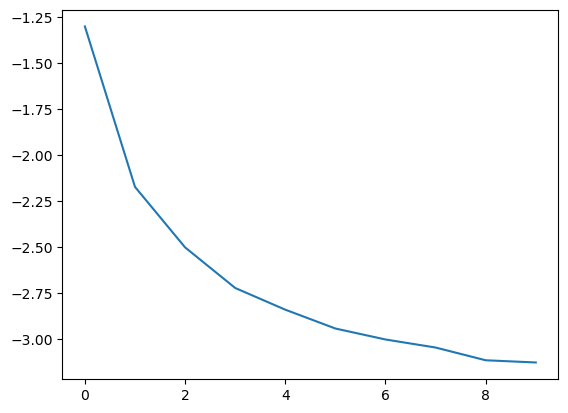

In [25]:
plt.plot(np.log(val_loss))

## 3. Test

In [30]:
with open('/home/amir/inverse_prob/params_for_noise_tuning/manu/AM_Extra1_post.npy', 'rb') as f:
    mesh, elem_X, P_xx_gt, P_yy_gt, node_params, Lambda_params, val_loss, metrics, t_hist, F_xx_mean, F_yy_mean, F_xy_mean, F_yx_mean= pickle.load(f)
common_params, sample_params = split_c_s_params_iso(node_params)
_, unravel = ravel_pytree(sample_params)
NODE_w_unravel = lambda params: NODE_model_iso(merge_c_s_params_iso(common_params, unravel(params)))

In [31]:
cell_type = get_meshio_cell_type('QUAD4')
Nx, Ny = 50, 50
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh2 = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
elem_X = mesh2.points[mesh2.cells].mean(axis=1)

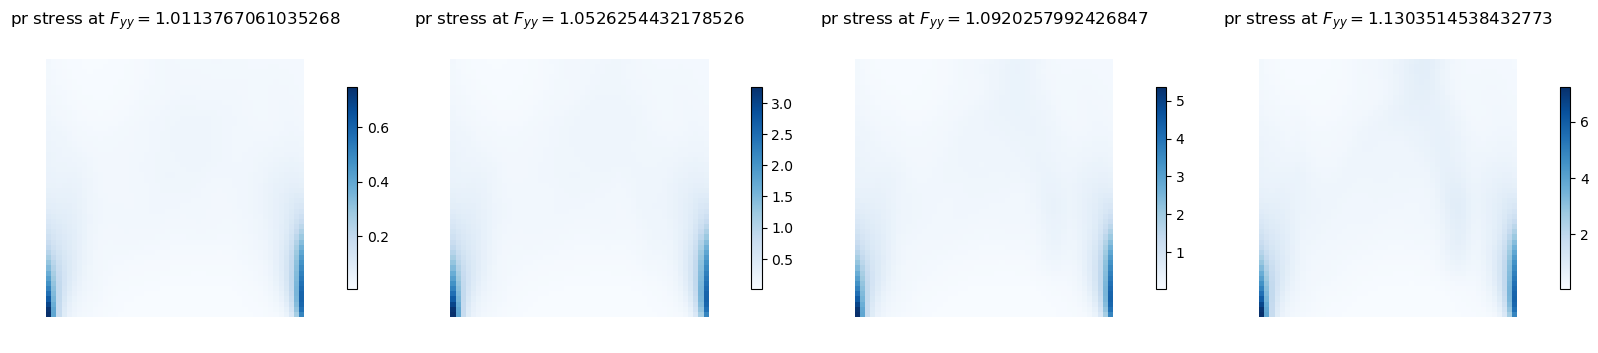

In [33]:
# Stiffness across the domain
fig, axes = plt.subplots(1,4,figsize=(20,8))
lmb_hist = [1.2, 1.3, 1.4, 1.5 , 1.6]

extents = [[0.018, 0.021],
           [0.07, 0.08],
           [0.115, 0.13],
           [0.155, 0.17]]
for F_xx, F_yy, F_xy, F_yx, ax, extent in zip(F_xx_mean, F_yy_mean, F_xy_mean, F_yx_mean, axes.T, extents):
    F = np.array([[F_xx, F_xy],
                  [F_yx, F_yy]])
    ugrad = F - np.eye(2)

    params_pr = ff_nn(elem_X, Lambda_params)

    c_elem_pr = []
    for params_pr_i in params_pr:
        c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[1,1])
    plotmesh(mesh2.cells, mesh2.points, c_elem_pr, title='pr stress at $F_{yy}=$' + str(F_yy), ax=ax, ec='None'); 


# p1 = np.array([[0.50, 0.37]])
# p2 = np.array([[0.85, 0.60]])
# axes[1,3].plot(p1[:,0], p1[:,1], 'ro')
# axes[1,3].plot(p2[:,0], p2[:,1], 'ro')

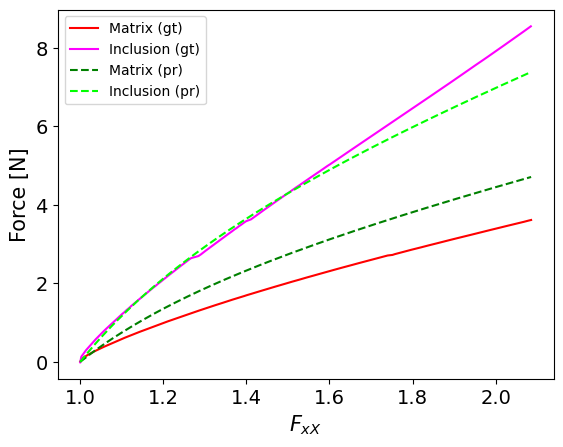

In [45]:
p1 = np.array([[0.3, 0.4]])
p2 = np.array([[0.9, 0.4]])
with open('/home/amir/inverse_prob/params_for_noise_tuning/manu/soft_homo.npy', 'rb') as f:
    x,y,F_hist_mtrx,_,force_mtrx = pickle.load(f)
F_hist_mtrx = F_hist_mtrx.mean(axis=1)

with open('/home/amir/inverse_prob/params_for_noise_tuning/manu/stiff2_homo.npy', 'rb') as f:
    x,y,F_hist_incl,_,force_incl = pickle.load(f)
F_hist_incl = F_hist_incl.mean(axis=1)

fig, ax = plt.subplots()
ax.plot(F_hist_mtrx[:,1,1], force_mtrx, label='Matrix (gt)',color='red')
ax.plot(F_hist_incl[:,1,1], force_incl, label='Inclusion (gt)',color='magenta')
# ax.set(xlabel='$F_{xx}$ [-]', ylabel='Force [N]')
ax.set_xlabel(r'$F_{xX}$',fontsize=15)
ax.set_ylabel(r'Force [N]',fontsize=15)
ax.legend(); 


p1_data = []
p2_data = []
# for F_xx, F_xy, F_yx, F_yy in zip(F_xx_mean, F_xy_mean, F_yx_mean, F_yy_mean):
for F in F_hist_mtrx:
    F_xx, F_xy, F_yx, F_yy = F[0,0], F[0,1], F[1,0], F[1,1]
    F = np.array([[F_xx, F_xy],
                  [F_yx, F_yy]])
    ugrad = F - np.eye(2)

    params_p1 = ff_nn(p1, Lambda_params)[0]
    p1_data.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_p1, 2)[1,1])

    params_p2 = ff_nn(p2, Lambda_params)[0]
    p2_data.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_p2, 2)[1,1])


fig.gca().set_prop_cycle(None)
ax.plot(F_hist_mtrx[:,1,1], p2_data, '--', label='Matrix (pr)',color='green')
ax.plot(F_hist_mtrx[:,1,1], p1_data, '--', label='Inclusion (pr)',color='lime')
ax.tick_params(axis='both', labelsize=14)
ax.legend()